# 03 - Aggregate and plot

Headline figure and companions from `aggregates*.csv` and the per-run metrics; numpy, pandas and matplotlib only.

Outputs in `figures/`: `bias_vs_training_events`, `companions`, `attribution_grid`, `paired_bias_difference` (png and pdf) and `summary_table.md`.

In [1]:
import os, sys, json, math
from pathlib import Path
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    def _find_scan_dir():
        """Locate the folder holding nsbi_scan.py on Drive (any folder name works)."""
        import glob as _glob
        cands = ["/content/drive/MyDrive/Research/NSBI/datascan",
                 "/content/drive/MyDrive/Research/NSBI/Training Statistics Scan"]
        for pat in ("/content/drive/MyDrive/Research/NSBI/*/nsbi_scan.py",
                    "/content/drive/MyDrive/*/nsbi_scan.py",
                    "/content/drive/MyDrive/*/*/nsbi_scan.py"):
            if any(os.path.isfile(os.path.join(c, "nsbi_scan.py")) for c in cands):
                break
            cands += sorted({os.path.dirname(p) for p in _glob.glob(pat)})
        for c in cands:
            if os.path.isfile(os.path.join(c, "nsbi_scan.py")):
                return c
        raise FileNotFoundError("nsbi_scan.py not found on Drive: copy the whole scan folder "
                                "(nsbi_scan.py + notebooks) under MyDrive/Research/NSBI/ and rerun this cell")
    SCAN_DIR = _find_scan_dir()
else:
    SCAN_DIR = os.getcwd()
    if not os.path.isfile(os.path.join(SCAN_DIR, "nsbi_scan.py")):
        cand = os.path.dirname(globals().get("__vsc_ipynb_file__", ""))
        if cand and os.path.isfile(os.path.join(cand, "nsbi_scan.py")):
            SCAN_DIR = cand
    assert os.path.isfile(os.path.join(SCAN_DIR, "nsbi_scan.py")), \
        f"nsbi_scan.py not found in {SCAN_DIR!r}; start Jupyter in the 'Training Statistics Scan' folder"
sys.path.insert(0, SCAN_DIR)
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm
import nsbi_scan as ns
print("nsbi_scan from", ns.__file__)

nsbi_scan from /home/ubuntu/datascan/nsbi_scan.py


In [2]:
# ============================ CONFIG (edit here) ============================
LOCAL_ROOT_DEFAULT = r"G:/My Drive/Research/NSBI/datascan"
                                                             # the env var NSBI_SCAN_ROOT overrides it)
RESULTS_DIR = None
X_TASK = "sig_over_bkg"
REF_VARIANT = "pretrained"
DECISION_FRACTION = 0.25
ATTR_SEED = 0
SAVE_FORMATS = ("png", "pdf")
DPI = 150
# ============================================================================
ROOT = SCAN_DIR if IN_COLAB else ns.resolve_root(LOCAL_ROOT_DEFAULT)
assert (Path(ROOT) / "scan_config.json").is_file(), \
    f"no scan_config.json under {ROOT!r} - set NSBI_SCAN_ROOT or LOCAL_ROOT_DEFAULT (or run notebook 00)"
cfg = ns.ScanConfig.load(ROOT).with_root(ROOT)   # the saved config carries the Colab root
FIG_DIR = cfg.figures_dir
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("scan root :", cfg.root)
print("figures   :", FIG_DIR)

scan root : /home/ubuntu/datascan
figures   : /home/ubuntu/datascan/figures


In [3]:
def find_results_dir(root, explicit=None):
    cands = [Path(explicit)] if explicit else [Path(root), Path(root) / "results", Path(root) / "measurements", Path(root) / "figures"]
    for d in cands:
        if (d / "aggregates.csv").exists():
            return d
    raise FileNotFoundError(f"aggregates.csv not found in {[str(c) for c in cands]} - run notebook 02 first")

RESULTS_DIR = find_results_dir(cfg.root, RESULTS_DIR)
agg = pd.read_csv(RESULTS_DIR / "aggregates.csv")
per_seed = pd.read_csv(RESULTS_DIR / "aggregates_per_seed.csv")
mp = RESULTS_DIR / "measurements.csv"
meas = pd.read_csv(mp) if mp.exists() else None
runs = ns.collect_runs(cfg)
for df in (agg, per_seed) + ((meas,) if meas is not None else ()):   # exact float keys for merges / comparisons
    for c in ("frac_sig", "frac_sbi"):
        df[c] = df[c].round(4)
    df["mu_true"] = df["mu_true"].round(3)
if len(runs):
    runs["frac"] = runs["frac"].round(4)
print(f"tables from {RESULTS_DIR}: aggregates {len(agg)} rows, per-seed {len(per_seed)}, "
      f"measurements {len(meas) if meas is not None else 'n/a'}, completed runs {len(runs)}")

try:
    N_FULL = ns.training_events_for(cfg, 1.0, X_TASK)
except FileNotFoundError:
    r = runs[runs.task == X_TASK] if len(runs) else runs
    if not len(r):
        raise FileNotFoundError(f"data/summary.json missing under {cfg.data_dir} and no completed {X_TASK} run to infer "
                                "N_full from - sync data/ or run notebook 00")
    r = r.sort_values("frac", ascending=False).iloc[0]
    N_FULL = int(r.n_num_train) if r.frac >= 1.0 else int(round(r.n_num_train / r.frac))
    print(f"NOTE: data/summary.json not found; N_full = {N_FULL:,} taken from the {100 * r.frac:g}% {X_TASK} run (n_num_train)"
          + ("" if r.frac >= 1.0 else " - extrapolated, exact to +/- 2 events"))

def events_for(frac):
    f = float(frac)
    return N_FULL if f >= 1.0 else int(round(f * N_FULL))

def diagonal(df):
    d = df[np.isclose(df.frac_sig, df.frac_sbi)].copy()
    d["frac"] = d["frac_sig"]
    d["x"] = d["frac"].map(events_for)
    return d.sort_values(["variant", "mu_true", "frac"]).reset_index(drop=True)

ps_diag = diagonal(per_seed)
diag = diagonal(agg)
se = (ps_diag.groupby(["variant", "frac", "mu_true"], as_index=False)["bias_se_toys"].mean()
      .rename(columns={"bias_se_toys": "se_toys"}))
diag = diag.merge(se, on=["variant", "frac", "mu_true"], how="left")
diag["bias_err"] = np.where(diag["n_seeds"] > 1, diag["bias_seed_std"], diag["se_toys"])
diag["err_kind"] = np.where(diag["n_seeds"] > 1, "seed std", "toy SE")

if meas is not None:
    n_open = (meas.assign(n_open_toys=~np.isfinite(meas["width"]))
                  .groupby(["variant", "seed", "frac_sig", "frac_sbi", "mu_true"], as_index=False)["n_open_toys"].sum())
    n_open = n_open[n_open.n_open_toys > 0]
    if len(n_open):
        print("WARNING: toys whose 1-sigma interval hits the mu-grid boundary (open interval; excluded from the width average):")
        display(n_open)
bad = diag[diag.halfwidth_mean.isna() | diag.width_mean.isna()]
if len(bad):
    print("WARNING: points whose 1-sigma interval is open on every toy (no width / sigma_stat; excluded from the decision rule):")
    display(bad[["variant", "mu_true", "frac", "n_seeds", "bias_mean"]])

VARIANT_STYLE = {"scratch": ("C0", "o"), "pretrained": ("C1", "s"), "frozen": ("C2", "^")}
VARIANT_LABEL = {"scratch": "scratch (random init)", "pretrained": "pretrained (all layers fine-tuned)",
                 "frozen": "pretrained (frozen backbone)"}
MU_LS = {2.5: "-", 0.4: "--"}
MU_ROWS = [float(m) for m in sorted(diag.mu_true.unique(), reverse=True)]   # mu_true = 2.5 on top, 0.4 below
VARIANTS_PRESENT = [v for v in VARIANT_STYLE if v in set(diag.variant)]
for k, v in enumerate(sorted(set(diag.variant) - set(VARIANT_STYLE))):
    VARIANT_STYLE[v], VARIANT_LABEL[v] = (f"C{3 + k}", "x"), v
    VARIANTS_PRESENT.append(v)
    print(f"NOTE: variant {v!r} has no predefined style/label - drawn with a fallback colour and marker")
FRACS = [float(f) for f in sorted(diag.frac.unique())]
print("variants:", VARIANTS_PRESENT, "| fractions:", FRACS, "| mu_true:", MU_ROWS, "| N_full =", N_FULL)

def add_fraction_axis(ax, label=True):
    # secondary x-axis on top: fraction of the training split in percent
    sec = ax.secondary_xaxis("top", functions=(lambda x: 100.0 * x / N_FULL, lambda p: p * N_FULL / 100.0))
    sec.set_xticks([100.0 * f for f in FRACS])
    sec.set_xticklabels([f"{100 * f:g}%" for f in FRACS])
    sec.xaxis.set_minor_formatter(mticker.NullFormatter())
    sec.tick_params(which="minor", length=0)
    if label:
        sec.set_xlabel("fraction of the training split")
    return sec

def save_fig(fig, stem):
    for fmt in SAVE_FORMATS:
        fig.savefig(FIG_DIR / f"{stem}.{fmt}", dpi=DPI, bbox_inches="tight")
    print("saved", FIG_DIR / f"{stem}.[{'|'.join(SAVE_FORMATS)}]")

X_LABEL = f"training events ({'signal' if X_TASK == 'sig_over_bkg' else 'SBI'} hypothesis)"
display(diag[["variant", "mu_true", "frac", "x", "n_seeds", "bias_mean", "bias_seed_std", "se_toys", "bias_err", "err_kind",
              "halfwidth_mean", "bias_over_sigma_mean"]].round(4))

tables from /home/ubuntu/datascan: aggregates 20 rows, per-seed 20, measurements 960, completed runs 20


,variant,seed,frac_sig,frac_sbi,mu_true,n_open_toys
1,pretrained,0,0.01,0.01,2.5,37
3,pretrained,0,0.03,0.03,2.5,48
4,pretrained,0,0.10,0.10,0.4,25
5,pretrained,0,0.10,0.10,2.5,48
11,scratch,0,0.01,0.01,2.5,17


,variant,mu_true,frac,n_seeds,bias_mean
6,pretrained,2.5,0.03,1,-2.5
7,pretrained,2.5,0.10,1,-2.5


variants: ['scratch', 'pretrained'] | fractions: [0.01, 0.03, 0.1, 0.3, 1.0] | mu_true: [2.5, 0.4] | N_full = 1213905


,variant,mu_true,frac,x,n_seeds,bias_mean,bias_seed_std,se_toys,bias_err,err_kind,halfwidth_mean,bias_over_sigma_mean
0,pretrained,0.4,0.01,12139,1,0.5306,NaN,0.0197,0.0197,toy SE,0.0813,6.5266
1,pretrained,0.4,0.03,36417,1,0.5937,NaN,0.0035,0.0035,toy SE,0.0595,9.9851
2,pretrained,0.4,0.10,121390,1,-0.3859,NaN,0.0028,0.0028,toy SE,0.0160,-24.1684
3,pretrained,0.4,0.30,364172,1,0.5521,NaN,0.0206,0.0206,toy SE,0.1667,3.3118
4,pretrained,0.4,1.00,1213905,1,0.0561,NaN,0.0276,0.0276,toy SE,0.4042,0.1387
5,pretrained,2.5,0.01,12139,1,-2.0771,NaN,0.1132,0.1132,toy SE,0.2687,-7.7304
6,pretrained,2.5,0.03,36417,1,-2.5000,NaN,0.0000,0.0000,toy SE,NaN,NaN
7,pretrained,2.5,0.10,121390,1,-2.5000,NaN,0.0000,0.0000,toy SE,NaN,NaN
8,pretrained,2.5,0.30,364172,1,-0.2241,NaN,0.0179,0.0179,toy SE,0.2394,-0.9362
9,pretrained,2.5,1.00,1213905,1,-0.1733,NaN,0.0111,0.0111,toy SE,0.2910,-0.5957


saved /home/ubuntu/datascan/figures/bias_vs_training_events.[png|pdf]


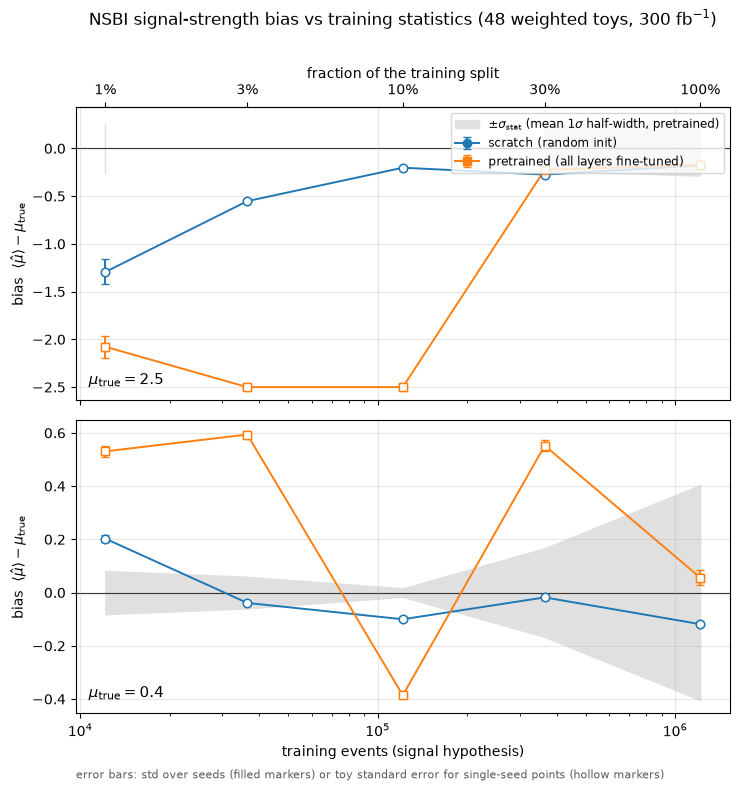

In [4]:
fig, axes = plt.subplots(len(MU_ROWS), 1, figsize=(7.5, 3.9 * len(MU_ROWS)), sharex=True)
axes = np.atleast_1d(axes)
for ax, mu in zip(axes, MU_ROWS):
    d = diag[diag.mu_true == mu]
    ref = d[d.variant == REF_VARIANT].sort_values("x")
    if len(ref):
        ax.fill_between(ref.x, -ref.halfwidth_mean, ref.halfwidth_mean, color="0.88", zorder=0,
                        label=rf"$\pm\sigma_{{\rm stat}}$ (mean 1$\sigma$ half-width, {REF_VARIANT})")
    ax.axhline(0.0, color="k", lw=0.8, zorder=1)
    for v in VARIANTS_PRESENT:
        c, m = VARIANT_STYLE[v]
        dv = d[d.variant == v].sort_values("x")
        if not len(dv):
            continue
        ax.errorbar(dv.x, dv.bias_mean, yerr=dv.bias_err, color=c, marker=m, ms=6, ls="-", lw=1.4, capsize=3,
                    label=VARIANT_LABEL[v], zorder=3)
        single = dv[dv.n_seeds == 1]
        if len(single):
            ax.plot(single.x, single.bias_mean, ls="none", marker=m, ms=6, mfc="white", mec=c, zorder=4)
    ax.set_xscale("log")
    ax.set_ylabel(r"bias  $\langle\hat{\mu}\rangle - \mu_{\rm true}$")
    ax.text(0.02, 0.04, rf"$\mu_{{\rm true}} = {mu:g}$", transform=ax.transAxes, va="bottom", fontsize=11)
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", fontsize=8.5)
axes[-1].set_xlabel(X_LABEL)
add_fraction_axis(axes[0])
axes[0].set_title(r"NSBI signal-strength bias vs training statistics (48 weighted toys, 300 fb$^{-1}$)", pad=30)
fig.text(0.5, -0.005, "error bars: std over seeds (filled markers) or toy standard error for single-seed points (hollow markers)",
         ha="center", fontsize=8, color="0.35")
fig.tight_layout()
save_fig(fig, "bias_vs_training_events")
plt.show()

saved /home/ubuntu/datascan/figures/companions.[png|pdf]


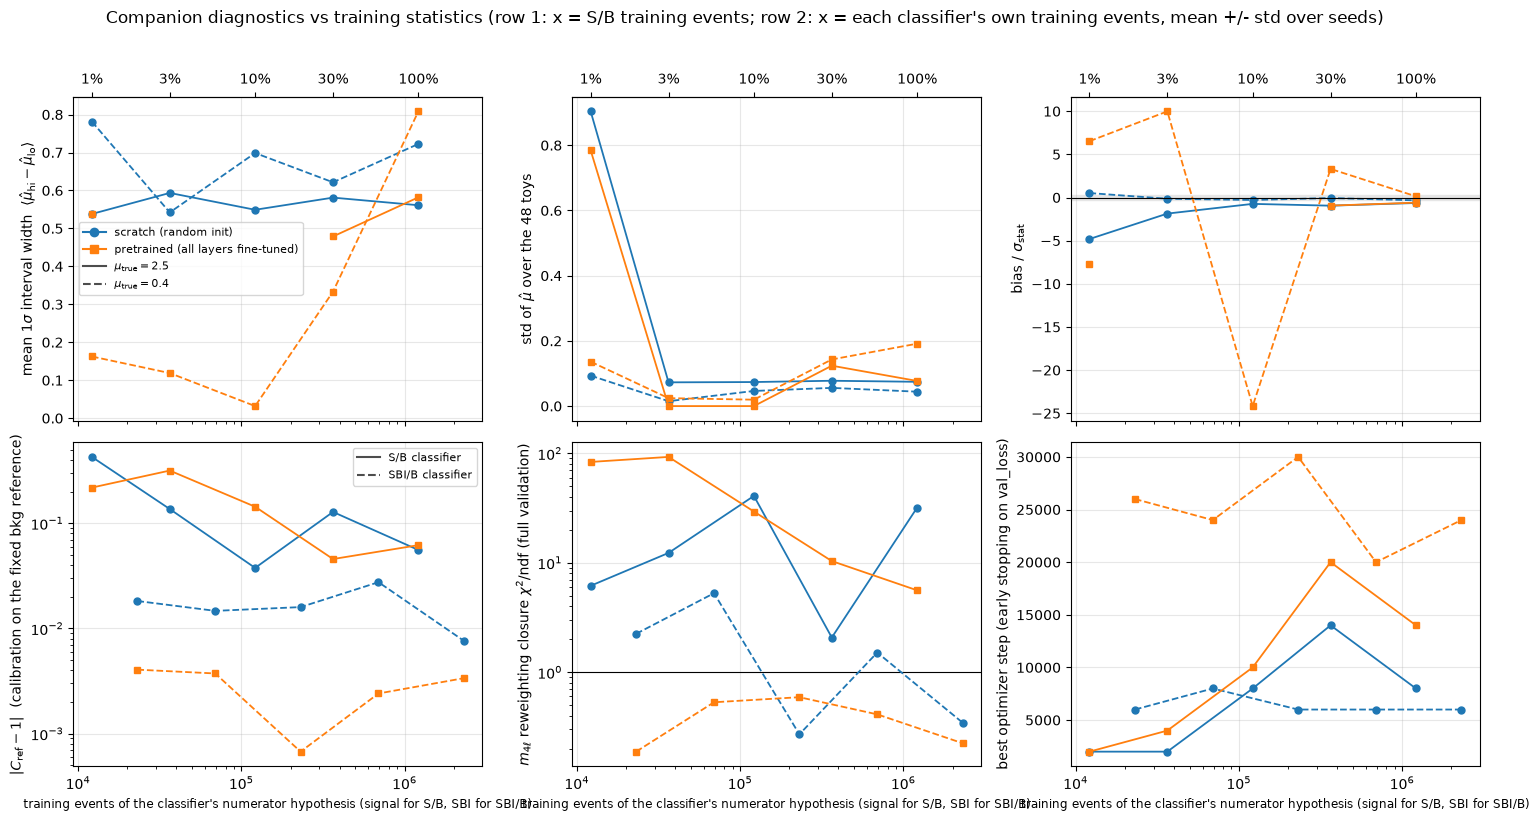

,variant,task,frac,x,n_seeds,abs_C_ref_m1_mean,closure_chi2_ndf_mean,best_step_mean,val_auc_full_mean,val_bce_full_mean
0,pretrained,sbi_over_bkg,0.01,23051,1,0.0041,0.1876,26000.0,0.5056,0.6927
1,pretrained,sbi_over_bkg,0.03,69152,1,0.0037,0.5306,24000.0,0.5071,0.6926
2,pretrained,sbi_over_bkg,0.10,230506,1,0.0007,0.5903,30000.0,0.5059,0.6927
3,pretrained,sbi_over_bkg,0.30,691517,1,0.0024,0.4113,20000.0,0.5058,0.6927
4,pretrained,sbi_over_bkg,1.00,2305058,1,0.0034,0.2240,24000.0,0.5058,0.6927
5,pretrained,sig_over_bkg,0.01,12139,1,0.2184,83.4419,2000.0,0.8630,0.4637
6,pretrained,sig_over_bkg,0.03,36417,1,0.3170,92.7621,4000.0,0.8706,0.4463
7,pretrained,sig_over_bkg,0.10,121390,1,0.1436,29.3841,10000.0,0.8758,0.4375
8,pretrained,sig_over_bkg,0.30,364172,1,0.0457,10.3619,20000.0,0.8809,0.4288
9,pretrained,sig_over_bkg,1.00,1213905,1,0.0619,5.5952,14000.0,0.8799,0.4305


In [5]:
run_cols = ["C_ref", "abs_C_ref_m1", "closure_chi2_ndf", "best_step", "best_epoch", "val_auc_full", "val_bce_full"]
if len(runs):
    runs["abs_C_ref_m1"] = (runs["C_ref"] - 1.0).abs()
    x_agg = {"x": ("n_num_train", "first")} if "n_num_train" in runs.columns else {}
    run_agg = runs.groupby(["variant", "task", "frac"], as_index=False).agg(
        n_seeds=("seed", "size"), **x_agg,
        **{f"{c}_mean": (c, "mean") for c in run_cols},
        **{f"{c}_std": (c, "std") for c in run_cols})
    if "x" not in run_agg.columns:
        run_agg["x"] = [ns.training_events_for(cfg, f, t) for f, t in zip(run_agg.frac, run_agg.task)]
else:
    run_agg = pd.DataFrame()
    print("no completed runs found under", cfg.runs_dir, "- row 2 will be empty")

TASK_LS = {"sig_over_bkg": "-", "sbi_over_bkg": "--"}
TASK_LABEL = {"sig_over_bkg": "S/B classifier", "sbi_over_bkg": "SBI/B classifier"}
X_LABEL_RUNS = "training events of the classifier's numerator hypothesis (signal for S/B, SBI for SBI/B)"

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
meas_panels = [("width_mean", r"mean 1$\sigma$ interval width  $\langle\hat{\mu}_{\rm hi} - \hat{\mu}_{\rm lo}\rangle$", False),
               ("std_muhat_mean", r"std of $\hat{\mu}$ over the 48 toys", False),
               ("bias_over_sigma_mean", r"bias / $\sigma_{\rm stat}$", False)]
for ax, (col, ylabel, logy) in zip(axes[0], meas_panels):
    for v in VARIANTS_PRESENT:
        c, m = VARIANT_STYLE[v]
        for mu in MU_ROWS:
            dv = diag[(diag.variant == v) & (diag.mu_true == mu)].sort_values("x")
            if len(dv):
                ax.plot(dv.x, dv[col], color=c, marker=m, ls=MU_LS.get(mu, ":"), lw=1.3, ms=5)
    if col == "bias_over_sigma_mean":
        ax.axhline(0.0, color="k", lw=0.8)
        ax.axhspan(-DECISION_FRACTION, DECISION_FRACTION, color="0.9", zorder=0)   # decision-rule tolerance
    ax.set_ylabel(ylabel)
    ax.set_xscale("log")
    ax.grid(alpha=0.3)
    if logy:
        ax.set_yscale("log")

run_panels = [("abs_C_ref_m1", r"$|C_{\rm ref} - 1|$  (calibration on the fixed bkg reference)", True),
              ("closure_chi2_ndf", r"$m_{4\ell}$ reweighting closure $\chi^2$/ndf (full validation)", True),
              ("best_step", "best optimizer step (early stopping on val_loss)", False)]
for ax, (col, ylabel, logy) in zip(axes[1], run_panels):
    if len(run_agg):
        for v in VARIANTS_PRESENT:
            c, m = VARIANT_STYLE[v]
            for task, ls in TASK_LS.items():
                dv = run_agg[(run_agg.variant == v) & (run_agg.task == task)].sort_values("x")
                if not len(dv):
                    continue
                y = dv[f"{col}_mean"].to_numpy(float)
                yerr = dv[f"{col}_std"].fillna(0.0).to_numpy(float)
                if logy:
                    y = np.where(y > 0, y, np.nan)
                    yerr = np.vstack([np.minimum(yerr, 0.95 * np.nan_to_num(y)), yerr])   # keep the lower bar positive on a log axis
                ax.errorbar(dv.x, y, yerr=yerr, color=c, marker=m, ls=ls, lw=1.3, ms=5, capsize=2)
    ax.set_ylabel(ylabel)
    ax.set_xscale("log")
    ax.grid(alpha=0.3)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(X_LABEL_RUNS, fontsize=8.5)
axes[1, 1].axhline(1.0, color="k", lw=0.8)

h_var = [Line2D([], [], color=VARIANT_STYLE[v][0], marker=VARIANT_STYLE[v][1], ls="-", label=VARIANT_LABEL[v]) for v in VARIANTS_PRESENT]
h_mu = [Line2D([], [], color="0.3", ls=MU_LS.get(mu, ":"), label=rf"$\mu_{{\rm true}} = {mu:g}$") for mu in MU_ROWS]
h_task = [Line2D([], [], color="0.3", ls=ls, label=TASK_LABEL[t]) for t, ls in TASK_LS.items()]
axes[0, 0].legend(handles=h_var + h_mu, fontsize=8, loc="best")
axes[1, 0].legend(handles=h_task, fontsize=8, loc="best")
for ax in axes[0]:
    add_fraction_axis(ax, label=False)
fig.suptitle("Companion diagnostics vs training statistics (row 1: x = S/B training events; "
             "row 2: x = each classifier's own training events, mean +/- std over seeds)", y=1.02)
fig.tight_layout()
save_fig(fig, "companions")
plt.show()
if len(run_agg):
    display(run_agg[["variant", "task", "frac", "x", "n_seeds", "abs_C_ref_m1_mean", "closure_chi2_ndf_mean",
                     "best_step_mean", "val_auc_full_mean", "val_bce_full_mean"]].round(4))

In [6]:
attr = per_seed[per_seed.seed == ATTR_SEED].copy()
off = attr[~np.isclose(attr.frac_sig, attr.frac_sbi)]
if len(off) == 0:
    print(f"no off-diagonal (f_sig != f_sbi) measurements for seed {ATTR_SEED} - "
          "run notebook 02 with diagonal_only=False to fill the attribution grid; skipping")
else:
    vs = [v for v in VARIANTS_PRESENT if v in set(off.variant)]
    fig, axes = plt.subplots(len(MU_ROWS), len(vs), figsize=(4.4 * len(vs) + 1.2, 3.9 * len(MU_ROWS)),
                             squeeze=False, layout="constrained")
    for i, mu in enumerate(MU_ROWS):
        dmu = attr[(attr.mu_true == mu) & attr.variant.isin(vs)]                    # only the variants drawn in this row
        vmax = max(float(np.nanmax(np.abs(dmu.bias))) if len(dmu) else 0.0, 1e-3)     # symmetric scale per mu_true row
        norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
        for j, v in enumerate(vs):
            ax = axes[i, j]
            piv = dmu[dmu.variant == v].pivot_table(index="frac_sbi", columns="frac_sig", values="bias", aggfunc="mean")
            piv = piv.reindex(index=sorted(piv.index), columns=sorted(piv.columns))
            z = piv.to_numpy(float)
            im = ax.imshow(z, origin="lower", cmap="RdBu_r", norm=norm, aspect="auto")
            ax.set_xticks(range(len(piv.columns)))
            ax.set_xticklabels([f"{100 * f:g}%" for f in piv.columns])
            ax.set_yticks(range(len(piv.index)))
            ax.set_yticklabels([f"{100 * f:g}%" for f in piv.index])
            for (r, c), val in np.ndenumerate(z):
                if np.isfinite(val):
                    ax.text(c, r, f"{val:+.2f}", ha="center", va="center", fontsize=8,
                            color="white" if abs(val) > 0.6 * vmax else "black")
            ax.set_xlabel("f (S/B classifier)")
            ax.set_ylabel("f (SBI/B classifier)")
            ax.set_title(rf"{VARIANT_LABEL[v]},  $\mu_{{\rm true}} = {mu:g}$", fontsize=10)
        fig.colorbar(im, ax=axes[i, :].tolist(), label=r"bias  $\langle\hat{\mu}\rangle - \mu_{\rm true}$", shrink=0.9)
    fig.suptitle(f"Attribution grid (seed {ATTR_SEED}): bias when the two classifiers use different training fractions")
    save_fig(fig, "attribution_grid")
    plt.show()

no off-diagonal (f_sig != f_sbi) measurements for seed 0 - run notebook 02 with diagonal_only=False to fill the attribution grid; skipping


saved /home/ubuntu/datascan/figures/paired_bias_difference.[png|pdf]


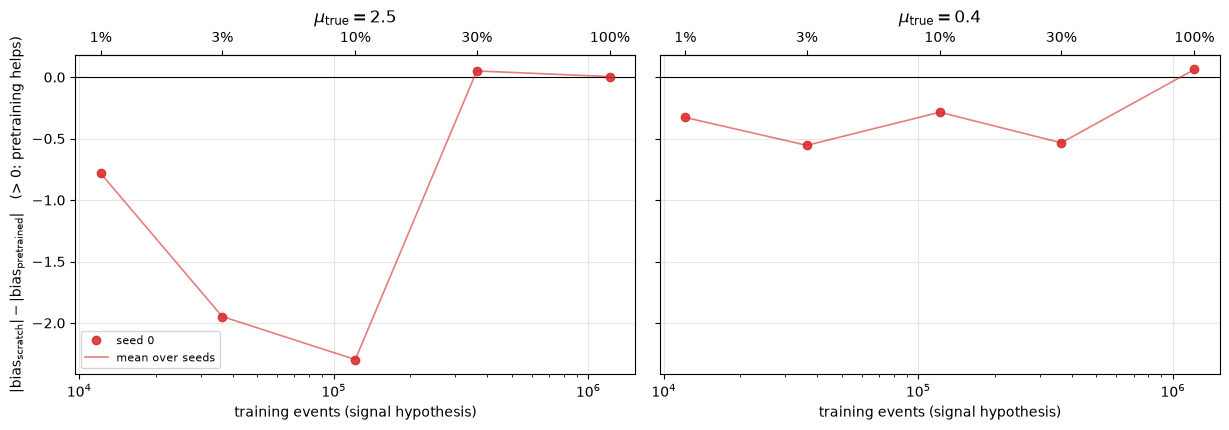

variant,frac,seed,mu_true,pretrained,scratch,abs_diff,x
1,0.01,0,2.5,-2.0771,-1.2938,-0.7833,12139
3,0.03,0,2.5,-2.5000,-0.5525,-1.9475,36417
5,0.10,0,2.5,-2.5000,-0.2024,-2.2976,121390
7,0.30,0,2.5,-0.2241,-0.2747,0.0505,364172
9,1.00,0,2.5,-0.1733,-0.1778,0.0044,1213905
0,0.01,0,0.4,0.5306,0.2025,-0.3281,12139
2,0.03,0,0.4,0.5937,-0.0388,-0.5548,36417
4,0.10,0,0.4,-0.3859,-0.1003,-0.2856,121390
6,0.30,0,0.4,0.5521,-0.0182,-0.5340,364172
8,1.00,0,0.4,0.0561,-0.1187,0.0627,1213905


In [7]:
pair = ps_diag.pivot_table(index=["frac", "seed", "mu_true"], columns="variant", values="bias").reset_index()
if not {"scratch", "pretrained"} <= set(pair.columns):
    print("need both scratch and pretrained runs for a paired comparison - skipping")
else:
    pair = pair.dropna(subset=["scratch", "pretrained"]).copy()
    pair["abs_diff"] = pair["scratch"].abs() - pair["pretrained"].abs()
    pair["x"] = pair["frac"].map(events_for)
    SEED_MARKERS = ["o", "s", "^", "D", "v", "P", "X"]
    seeds = sorted(pair.seed.unique())
    fig, axes = plt.subplots(1, len(MU_ROWS), figsize=(6.2 * len(MU_ROWS), 4.4), sharey=True, squeeze=False)
    for ax, mu in zip(axes[0], MU_ROWS):
        d = pair[pair.mu_true == mu]
        ax.axhline(0.0, color="k", lw=0.8)
        for k, s in enumerate(seeds):
            ds = d[d.seed == s].sort_values("x")
            jitter = 1.0 + 0.05 * (k - 0.5 * (len(seeds) - 1))
            ax.plot(ds.x * jitter, ds.abs_diff, ls="none", marker=SEED_MARKERS[k % len(SEED_MARKERS)], ms=6,
                    color="C3", alpha=0.85, label=f"seed {s}")
        dm = d.groupby("x", as_index=False)["abs_diff"].mean()
        ax.plot(dm.x, dm.abs_diff, color="C3", lw=1.2, alpha=0.6, label="mean over seeds")
        ax.set_xscale("log")
        ax.grid(alpha=0.3)
        ax.set_xlabel(X_LABEL)
        ax.set_title(rf"$\mu_{{\rm true}} = {mu:g}$")
        add_fraction_axis(ax, label=False)
    axes[0, 0].set_ylabel(r"$|{\rm bias}_{\rm scratch}| - |{\rm bias}_{\rm pretrained}|$   (> 0: pretraining helps)")
    axes[0, 0].legend(fontsize=8)
    fig.tight_layout()
    save_fig(fig, "paired_bias_difference")
    plt.show()
    display(pair.sort_values(["mu_true", "frac", "seed"], ascending=[False, True, True]).round(4))

In [8]:
def decision_table(diag, mu, a="scratch", b="pretrained"):
    da = diag[(diag.mu_true == mu) & (diag.variant == a)].set_index("frac")
    db = diag[(diag.mu_true == mu) & (diag.variant == b)].set_index("frac")
    ref = diag[(diag.mu_true == mu) & (diag.variant == REF_VARIANT)].set_index("frac")
    rows = []
    for f in sorted(set(da.index) & set(db.index) & set(ref.index)):
        ba, bb = float(da.loc[f, "bias_mean"]), float(db.loc[f, "bias_mean"])
        sep = abs(ba - bb)
        err = math.hypot(float(da.loc[f, "bias_err"]), float(db.loc[f, "bias_err"]))
        thr = DECISION_FRACTION * float(ref.loc[f, "halfwidth_mean"])
        rows.append({"frac": f, "x": events_for(f), f"bias_{a}": ba, f"bias_{b}": bb, "separation": sep, "sep_err": err,
                     "significant": sep > err, "threshold": thr, "thr_finite": bool(np.isfinite(thr)),
                     f"{a}_biased": abs(ba) > thr, f"{b}_unbiased": abs(bb) <= thr})
    t = pd.DataFrame(rows)
    if len(t):
        t["separates"] = t["significant"] & t["thr_finite"] & t[f"{a}_biased"] & t[f"{b}_unbiased"]
    return t

LADDER = sorted(float(f) for f in cfg.fractions)
def not_compared(t, lo=-np.inf, hi=np.inf):
    return [f for f in LADDER if lo < f < hi and not np.isclose(t.frac.to_numpy(float), f).any()]

def pct(fs):
    return ", ".join(f"{100 * f:g}%" for f in fs)

decision_msgs = []
for mu in MU_ROWS:
    t = decision_table(diag, mu)
    print(f"mu_true = {mu:g}")
    display(t.round(4))
    hit = t[t["separates"]] if len(t) else t
    if len(hit):
        f_hit = float(hit.frac.max())
        larger = t[t.frac > f_hit]
        if len(larger):
            f_next = float(larger.frac.min())
            gap = not_compared(t, f_hit, f_next)
            msg = (f"mu_true = {mu:g}: pretraining starts to help below {events_for(f_next):,} training events "
                   f"({100 * f_next:g}%, the next compared fraction"
                   + (f"; not compared in between: {pct(gap)}" if gap else "") + "); "
                   f"largest separated point: {100 * f_hit:g}% = {events_for(f_hit):,} events.")
        else:
            gap = not_compared(t, f_hit)
            msg = (f"mu_true = {mu:g}: pretraining helps already at the largest compared fraction "
                   f"({100 * f_hit:g}% = {events_for(f_hit):,} training events)"
                   + (f"; larger scan fractions not compared yet: {pct(gap)}." if gap else "."))
    elif len(t):
        f_min = float(t.frac.min())
        gap = not_compared(t, hi=f_min)
        msg = (f"mu_true = {mu:g}: no separation seen down to {100 * f_min:g}% ({events_for(f_min):,} training events)"
               + (f"; smaller scan fractions not compared yet: {pct(gap)}." if gap else "."))
    else:
        msg = f"mu_true = {mu:g}: no comparable scratch / pretrained points."
    decision_msgs.append(msg)
    print(msg)

mu_true = 2.5


,frac,x,bias_scratch,bias_pretrained,separation,sep_err,significant,threshold,thr_finite,scratch_biased,pretrained_unbiased,separates
0,0.01,12139,-1.2938,-2.0771,0.7833,0.1728,True,0.0672,True,True,False,False
1,0.03,36417,-0.5525,-2.5000,1.9475,0.0105,True,NaN,False,False,False,False
2,0.10,121390,-0.2024,-2.5000,2.2976,0.0106,True,NaN,False,False,False,False
3,0.30,364172,-0.2747,-0.2241,0.0505,0.0211,True,0.0599,True,True,False,False
4,1.00,1213905,-0.1778,-0.1733,0.0044,0.0155,False,0.0727,True,True,False,False


mu_true = 2.5: no separation seen down to 1% (12,139 training events).
mu_true = 0.4


,frac,x,bias_scratch,bias_pretrained,separation,sep_err,significant,threshold,thr_finite,scratch_biased,pretrained_unbiased,separates
0,0.01,12139,0.2025,0.5306,0.3281,0.0238,True,0.0203,True,True,False,False
1,0.03,36417,-0.0388,0.5937,0.6325,0.0041,True,0.0149,True,True,False,False
2,0.10,121390,-0.1003,-0.3859,0.2856,0.0073,True,0.0040,True,True,False,False
3,0.30,364172,-0.0182,0.5521,0.5703,0.0222,True,0.0417,True,False,False,False
4,1.00,1213905,-0.1187,0.0561,0.1748,0.0284,True,0.1011,True,True,True,True


mu_true = 0.4: pretraining helps already at the largest compared fraction (100% = 1,213,905 training events).


In [9]:
def fmt_bias(r):
    return f"{r.bias_mean:+.3f} +/- {r.bias_err:.3f}" + ("" if r.n_seeds > 1 else " (toy SE)")

def fmt_num(v, spec):
    return format(v, spec) if np.isfinite(v) else "open interval"     # 1-sigma interval hits the mu grid on every toy

tab = diag.sort_values(["mu_true", "variant", "frac"], ascending=[False, True, True])
lines = ["# Training-statistics scan: summary", "",
         f"Scan root `{cfg.root}`. x = training events of the {'signal' if X_TASK == 'sig_over_bkg' else 'SBI'} hypothesis "
         f"(N_full = {N_FULL:,}). Toys: 48 weighted MC subsets per mu_true at {cfg.lumi:g} fb^-1. "
         f"sigma_stat = mean 1-sigma half-width; the +/- is the std over seeds, or the toy standard error for single-seed points.", "",
         "| mu_true | variant | fraction | training events | seeds | bias +/- seed std | mean 1-sigma width | bias / sigma_stat |",
         "|---|---|---|---|---|---|---|---|"]
for _, r in tab.iterrows():
    lines.append(f"| {r.mu_true:g} | {r.variant} | {100 * r.frac:g}% | {int(r.x):,} | {int(r.n_seeds)} | {fmt_bias(r)} | "
                 f"{fmt_num(r.width_mean, '.3f')} | {fmt_num(r.bias_over_sigma_mean, '+.2f')} |")
lines += ["", "## Decision rule", "",
          f"Separation requires |bias_scratch - bias_pretrained| > sqrt(err_s^2 + err_p^2) and |bias_scratch| > {DECISION_FRACTION:g} sigma_stat "
          f"while |bias_pretrained| <= {DECISION_FRACTION:g} sigma_stat (sigma_stat from the {REF_VARIANT} variant). "
          "Points marked 'open interval' have no sigma_stat and cannot separate.", ""]
lines += [f"- {m}" for m in decision_msgs]
md_text = "\n".join(lines) + "\n"
(FIG_DIR / "summary_table.md").write_text(md_text, encoding="utf-8")
print("wrote", FIG_DIR / "summary_table.md")
try:
    from IPython.display import Markdown
    display(Markdown(md_text))
except Exception:
    print(md_text)
print("figures written:")
for p in sorted(FIG_DIR.iterdir()):
    print("  ", p.name)

wrote /home/ubuntu/datascan/figures/summary_table.md


# Training-statistics scan: summary

Scan root `/home/ubuntu/datascan`. x = training events of the signal hypothesis (N_full = 1,213,905). Toys: 48 weighted MC subsets per mu_true at 300 fb^-1. sigma_stat = mean 1-sigma half-width; the +/- is the std over seeds, or the toy standard error for single-seed points.

| mu_true | variant | fraction | training events | seeds | bias +/- seed std | mean 1-sigma width | bias / sigma_stat |
|---|---|---|---|---|---|---|---|
| 2.5 | pretrained | 1% | 12,139 | 1 | -2.077 +/- 0.113 (toy SE) | 0.537 | -7.73 |
| 2.5 | pretrained | 3% | 36,417 | 1 | -2.500 +/- 0.000 (toy SE) | open interval | open interval |
| 2.5 | pretrained | 10% | 121,390 | 1 | -2.500 +/- 0.000 (toy SE) | open interval | open interval |
| 2.5 | pretrained | 30% | 364,172 | 1 | -0.224 +/- 0.018 (toy SE) | 0.479 | -0.94 |
| 2.5 | pretrained | 100% | 1,213,905 | 1 | -0.173 +/- 0.011 (toy SE) | 0.582 | -0.60 |
| 2.5 | scratch | 1% | 12,139 | 1 | -1.294 +/- 0.130 (toy SE) | 0.538 | -4.81 |
| 2.5 | scratch | 3% | 36,417 | 1 | -0.553 +/- 0.011 (toy SE) | 0.593 | -1.86 |
| 2.5 | scratch | 10% | 121,390 | 1 | -0.202 +/- 0.011 (toy SE) | 0.549 | -0.74 |
| 2.5 | scratch | 30% | 364,172 | 1 | -0.275 +/- 0.011 (toy SE) | 0.581 | -0.95 |
| 2.5 | scratch | 100% | 1,213,905 | 1 | -0.178 +/- 0.011 (toy SE) | 0.561 | -0.63 |
| 0.4 | pretrained | 1% | 12,139 | 1 | +0.531 +/- 0.020 (toy SE) | 0.163 | +6.53 |
| 0.4 | pretrained | 3% | 36,417 | 1 | +0.594 +/- 0.004 (toy SE) | 0.119 | +9.99 |
| 0.4 | pretrained | 10% | 121,390 | 1 | -0.386 +/- 0.003 (toy SE) | 0.032 | -24.17 |
| 0.4 | pretrained | 30% | 364,172 | 1 | +0.552 +/- 0.021 (toy SE) | 0.333 | +3.31 |
| 0.4 | pretrained | 100% | 1,213,905 | 1 | +0.056 +/- 0.028 (toy SE) | 0.808 | +0.14 |
| 0.4 | scratch | 1% | 12,139 | 1 | +0.202 +/- 0.013 (toy SE) | 0.781 | +0.52 |
| 0.4 | scratch | 3% | 36,417 | 1 | -0.039 +/- 0.002 (toy SE) | 0.542 | -0.14 |
| 0.4 | scratch | 10% | 121,390 | 1 | -0.100 +/- 0.007 (toy SE) | 0.699 | -0.29 |
| 0.4 | scratch | 30% | 364,172 | 1 | -0.018 +/- 0.008 (toy SE) | 0.621 | -0.06 |
| 0.4 | scratch | 100% | 1,213,905 | 1 | -0.119 +/- 0.006 (toy SE) | 0.723 | -0.33 |

## Decision rule

Separation requires |bias_scratch - bias_pretrained| > sqrt(err_s^2 + err_p^2) and |bias_scratch| > 0.25 sigma_stat while |bias_pretrained| <= 0.25 sigma_stat (sigma_stat from the pretrained variant). Points marked 'open interval' have no sigma_stat and cannot separate.

- mu_true = 2.5: no separation seen down to 1% (12,139 training events).
- mu_true = 0.4: pretraining helps already at the largest compared fraction (100% = 1,213,905 training events).


figures written:
   02_nll_one_toy.png
   02_run_diagnostics.png
   bias_vs_training_events.pdf
   bias_vs_training_events.png
   companions.pdf
   companions.png
   paired_bias_difference.pdf
   paired_bias_difference.png
   summary_table.md


## Reading the headline figure

x: training events of the signal hypothesis at each fraction. y: mean best-fit mu over the 48 toys minus mu_true. Grey band: mean 1-sigma half-width of one fit. Error bars: std over seeds, or the toy standard error for single-seed points (hollow). The automatic decision line fires on single-seed noise and should not be quoted. The toys carry no Poisson fluctuation, so the toy spread is MC noise, not coverage.